In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Import the data

In [2]:
df_errors = pd.read_csv('../2-calculate-values/bootstrap_errors_normal_xthreat_sb_xg.csv').rename(columns={'sample_size': 'N'})
df_errors['M'] = df_errors['n_x'] * df_errors['n_y']
df_errors['1/sqrt(N)'] = 1/np.sqrt(df_errors['N'])
df_errors['Mlog(M)/sqrt(N)'] = df_errors['M']*np.log(df_errors['M'])*df_errors['1/sqrt(N)']

In [3]:
# Make the norm a dimension independent norm
for col in df_errors.columns.tolist():
    if '1_norm' in col:
        df_errors[col] = df_errors[col]/df_errors['M']
    if ' 2_norm' in col:
        df_errors[col] = df_errors[col]/np.sqrt(df_errors['M'])

# Quick inspection of data

In [4]:
df_errors.head(10)

,n_x,n_y,N,i_bootstrap,random_state,xT_error_1_norm,g_error_1_norm,xG_error_1_norm,prob_shot_error_1_norm,transition_matrix_error_1_norm,...,xT_error_inf_norm,g_error_inf_norm,xG_error_inf_norm,prob_shot_error_inf_norm,transition_matrix_error_inf_norm,transition_matrix_true_inf_norm,transition_matrix_resampled_inf_norm,M,1/sqrt(N),Mlog(M)/sqrt(N)
0,16,12,4000000,0,5176042,0.000235,0.000176,0.004511,0.000580,0.000403,...,0.005297,0.006123,0.136427,0.022223,0.131414,1.0,1.0,192,0.0005,0.50472
1,16,12,4000000,1,5176043,0.000312,0.000173,0.003848,0.000344,0.000401,...,0.009648,0.007491,0.076903,0.008385,0.117864,1.0,1.0,192,0.0005,0.50472
2,16,12,4000000,2,5176044,0.000248,0.000174,0.009482,0.000351,0.000414,...,0.007423,0.007622,0.995788,0.006650,0.132075,1.0,1.0,192,0.0005,0.50472
3,16,12,4000000,3,5176045,0.000384,0.000227,0.003574,0.000430,0.000438,...,0.013541,0.012028,0.025511,0.011811,0.133729,1.0,1.0,192,0.0005,0.50472
4,16,12,4000000,4,5176046,0.000275,0.000216,0.003235,0.000483,0.000433,...,0.011772,0.012947,0.024179,0.012102,0.139206,1.0,1.0,192,0.0005,0.50472
5,16,12,4000000,5,5176047,0.000255,0.000190,0.011653,0.000456,0.000424,...,0.010577,0.010558,0.992570,0.027178,0.135318,1.0,1.0,192,0.0005,0.50472
6,16,12,4000000,6,5176048,0.000178,0.000126,0.003717,0.000433,0.000423,...,0.006000,0.008826,0.056201,0.007857,0.137429,1.0,1.0,192,0.0005,0.50472
7,16,12,4000000,7,5176049,0.000315,0.000225,0.003661,0.000379,0.000428,...,0.008990,0.008073,0.042036,0.012317,0.125164,1.0,1.0,192,0.0005,0.50472
8,16,12,4000000,8,5176050,0.000268,0.000172,0.005493,0.000469,0.000433,...,0.010685,0.009466,0.317787,0.010998,0.122867,1.0,1.0,192,0.0005,0.50472
9,16,12,4000000,9,5176051,0.000194,0.000135,0.003705,0.000332,0.000404,...,0.008564,0.007997,0.032048,0.007486,0.126872,1.0,1.0,192,0.0005,0.50472


In [5]:
df_errors.describe()

,n_x,n_y,N,i_bootstrap,random_state,xT_error_1_norm,g_error_1_norm,xG_error_1_norm,prob_shot_error_1_norm,transition_matrix_error_1_norm,...,xT_error_inf_norm,g_error_inf_norm,xG_error_inf_norm,prob_shot_error_inf_norm,transition_matrix_error_inf_norm,transition_matrix_true_inf_norm,transition_matrix_resampled_inf_norm,M,1/sqrt(N),Mlog(M)/sqrt(N)
count,48000.000000,48000.000000,4.800000e+04,48000.000000,4.800000e+04,48000.000000,48000.000000,48000.000000,48000.000000,48000.000000,...,48000.000000,48000.000000,48000.000000,48000.000000,48000.000000,48000.0,4.800000e+04,48000.000000,48000.000000,48000.000000
mean,42.666667,32.000000,8.675000e+05,499.500000,4.004042e+06,0.002788,0.002007,0.007885,0.004549,0.001197,...,0.352133,0.352298,0.612523,0.382357,1.335572,1.0,1.000000e+00,1552.000000,0.001835,21.544314
std,15.776377,11.832283,1.240817e+06,288.677997,1.698297e+06,0.001805,0.001326,0.002677,0.003040,0.000556,...,0.298540,0.297000,0.348448,0.354952,0.548058,0.0,2.226982e-16,963.470466,0.000873,19.160724
min,16.000000,12.000000,1.000000e+05,0.000000,1.276042e+06,0.000133,0.000076,0.002916,0.000248,0.000294,...,0.002346,0.001812,0.024179,0.004351,0.106011,1.0,1.000000e+00,192.000000,0.000500,0.504720
25%,32.000000,24.000000,1.600000e+05,249.750000,2.917292e+06,0.001250,0.000858,0.005699,0.001980,0.000767,...,0.093048,0.092813,0.307732,0.092308,0.847845,1.0,1.000000e+00,768.000000,0.001164,6.437773
50%,44.000000,33.000000,3.050000e+05,499.500000,3.833542e+06,0.002401,0.001727,0.007658,0.003877,0.001121,...,0.250088,0.250088,0.548478,0.230769,1.543508,1.0,1.000000e+00,1464.000000,0.001843,16.074588
75%,56.000000,42.000000,7.975000e+05,749.250000,4.844791e+06,0.004041,0.002949,0.009964,0.006527,0.001567,...,0.666439,0.635488,0.984402,0.712121,1.811594,1.0,1.000000e+00,2352.000000,0.002512,31.120176
max,64.000000,48.000000,4.000000e+06,999.000000,8.705041e+06,0.008747,0.006414,0.020117,0.014307,0.003382,...,0.986597,0.999869,0.999820,1.000000,1.929577,1.0,1.000000e+00,3072.000000,0.003162,78.008388


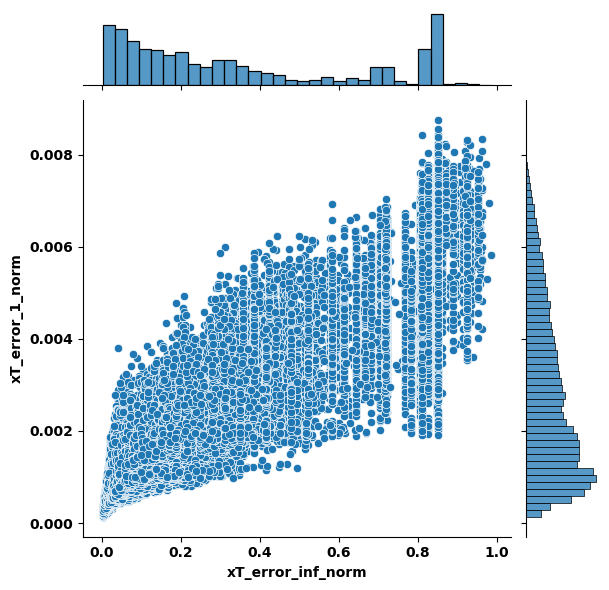

In [6]:
sns.jointplot(data=df_errors, x="xT_error_inf_norm", y="xT_error_1_norm")

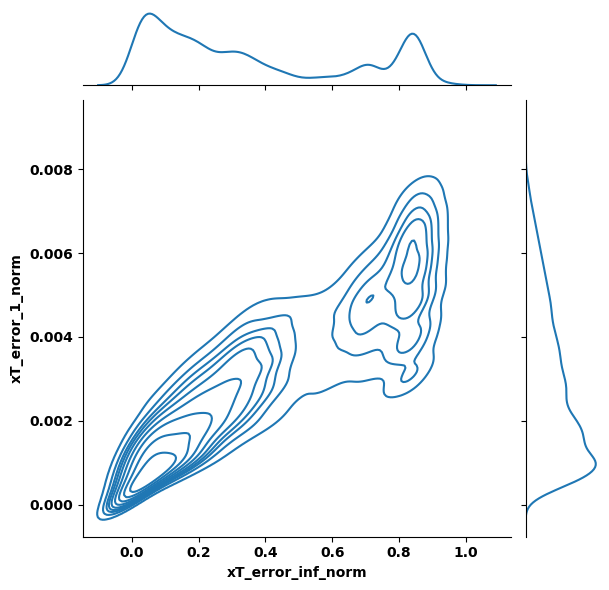

In [7]:
sns.jointplot(data=df_errors, 
              x="xT_error_inf_norm", 
              y="xT_error_1_norm",
              kind="kde"
              )

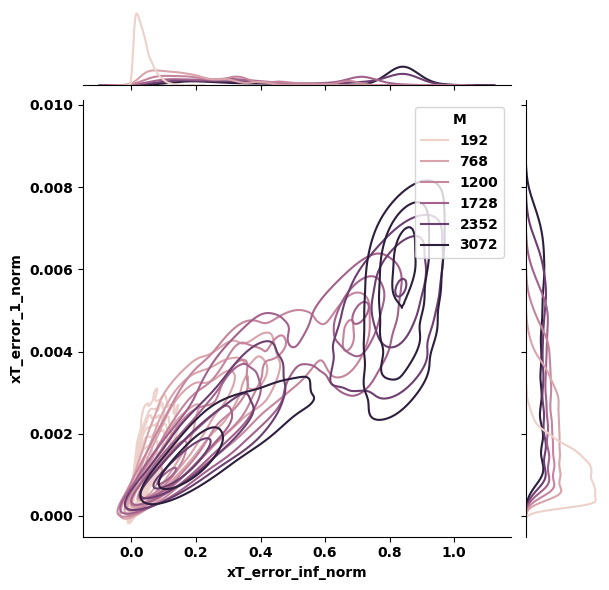

In [8]:
sns.jointplot(data=df_errors, 
              x="xT_error_inf_norm", 
              y="xT_error_1_norm",
              kind="kde",
              hue='M'
              )

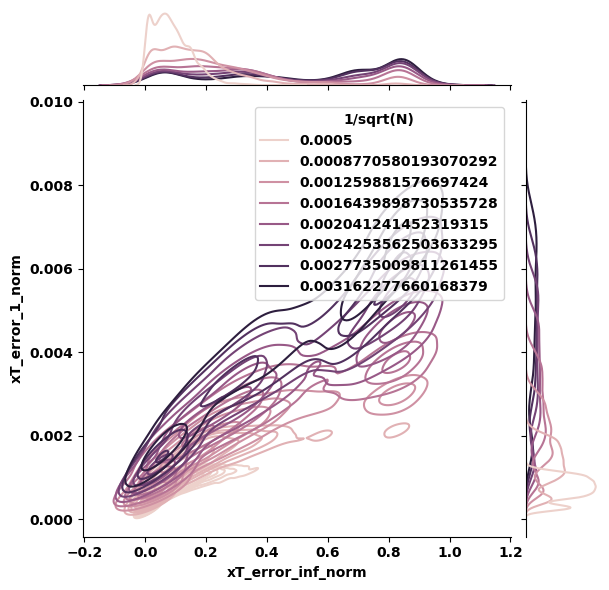

In [9]:
sns.jointplot(data=df_errors, 
              x="xT_error_inf_norm", 
              y="xT_error_1_norm",
              kind="kde",
              hue='1/sqrt(N)'
              )

## Infinity norm

<Axes: xlabel='xT_error_inf_norm', ylabel='Density'>

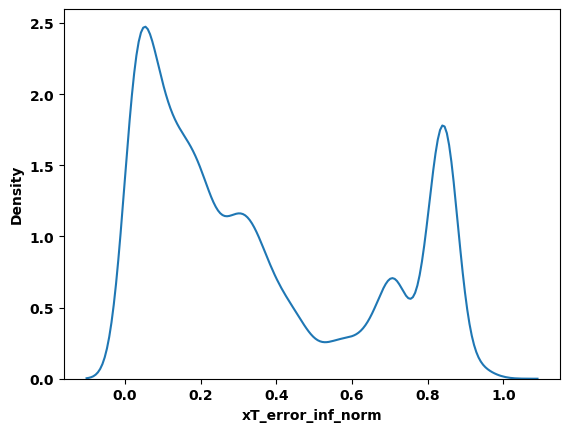

In [10]:
sns.kdeplot(data=df_errors, x='xT_error_inf_norm')

<Axes: xlabel='xT_error_inf_norm', ylabel='Density'>

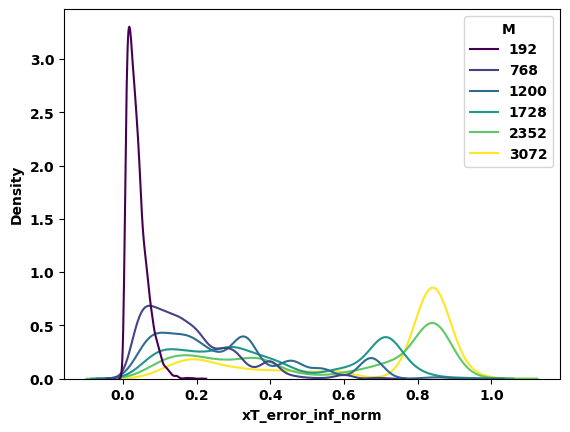

In [11]:
sns.kdeplot(data=df_errors, x='xT_error_inf_norm', hue='M', palette='viridis')

<Axes: xlabel='xT_error_inf_norm', ylabel='Density'>

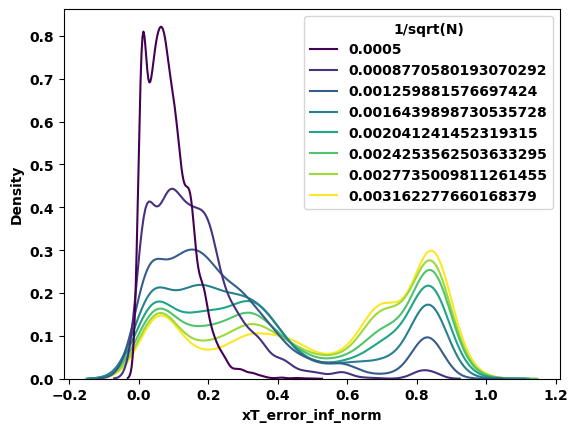

In [12]:
sns.kdeplot(data=df_errors, x='xT_error_inf_norm', hue='1/sqrt(N)', palette='viridis')

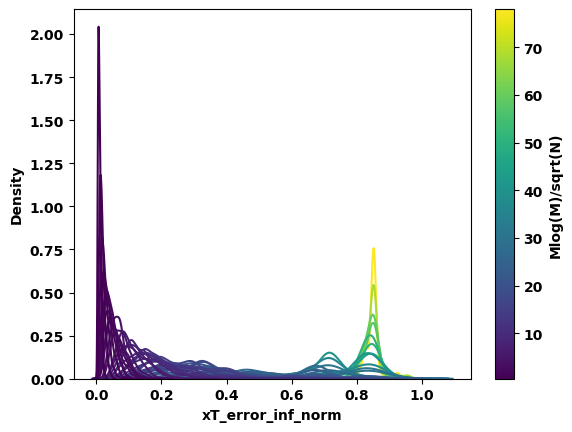

In [13]:
fig, ax = plt.subplots()
norm = plt.Normalize(df_errors['Mlog(M)/sqrt(N)'].min(), df_errors['Mlog(M)/sqrt(N)'].max())
sm = plt.cm.ScalarMappable(cmap='viridis', norm=norm)
sm.set_array([])

sns.kdeplot(
    data=df_errors, 
    x='xT_error_inf_norm', 
    hue='Mlog(M)/sqrt(N)', 
    palette='viridis',
    hue_norm=norm,
    ax=ax
)

# Remove the legend
ax.get_legend().remove()

# Add a color bar
cbar = plt.colorbar(sm, ax=ax)
cbar.set_label('Mlog(M)/sqrt(N)')

plt.show()

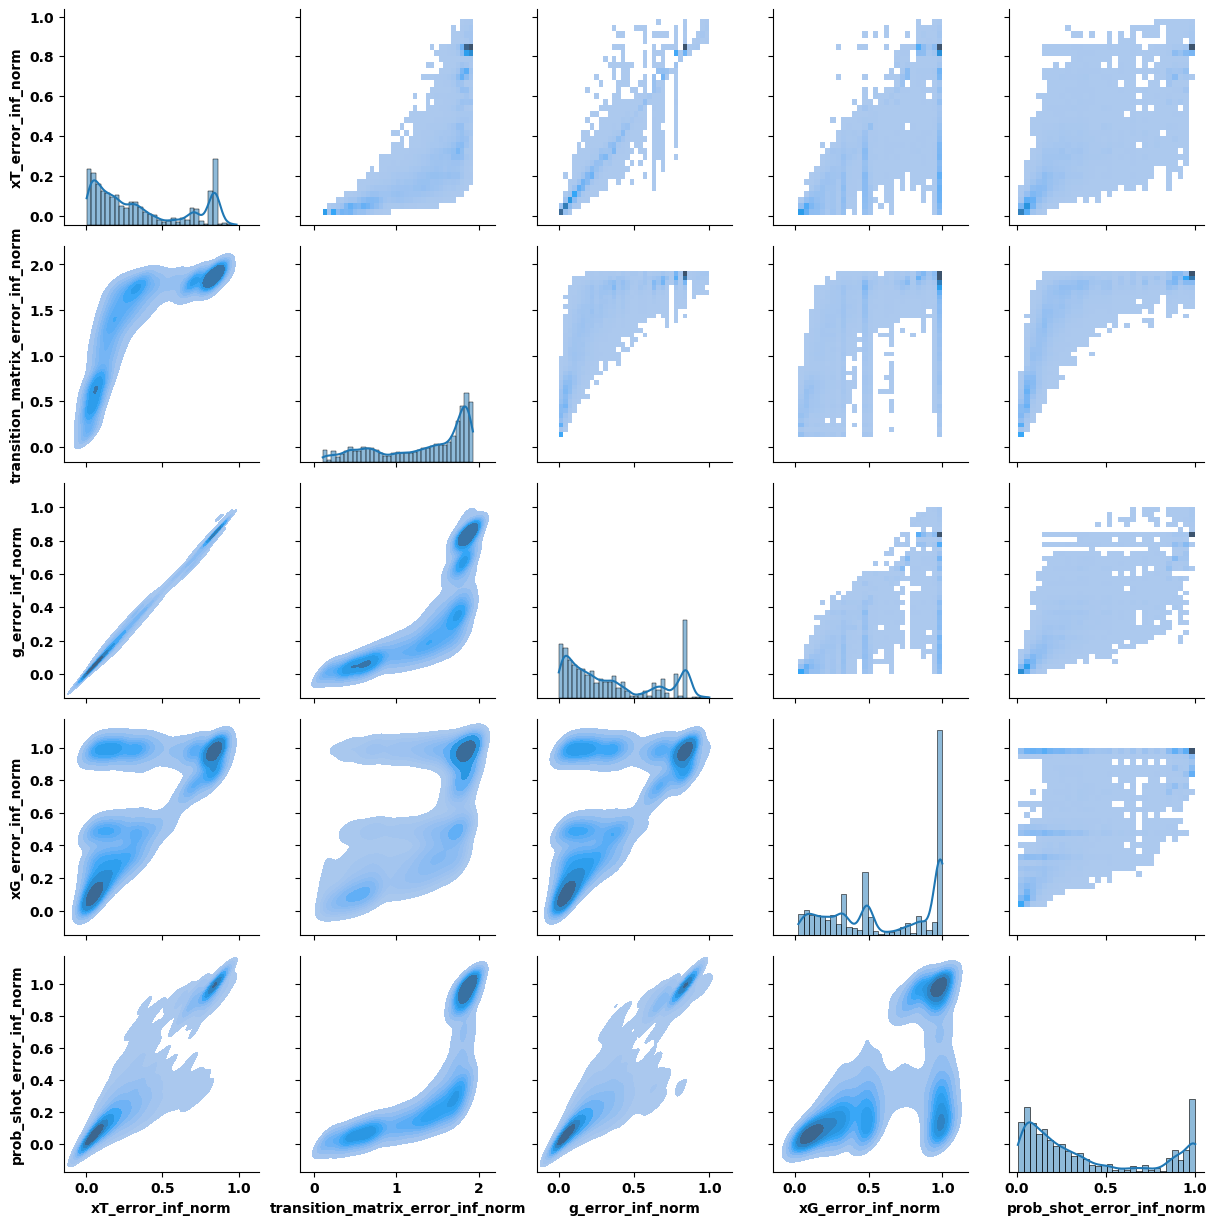

In [14]:
g = sns.PairGrid(df_errors[['xT_error_inf_norm', 'transition_matrix_error_inf_norm', 'g_error_inf_norm', 'xG_error_inf_norm', 'prob_shot_error_inf_norm']])
g.map_upper(sns.histplot)
g.map_lower(sns.kdeplot, fill=True)
g.map_diag(sns.histplot, kde=True)

It seems like the error in the g-vector has the strongest relation with the actual xT error with respect to the infinity norm. It is interesting to note that the g value is the xG value multiplied with the prob_shot value. <br>
At the same time, it looks like the xG error has generally very large errors. This is well-known behaviour from practice: there are often some spots at the pitch where almost no shots are taken. If the sample contains one shot where it has large values, this will be visible in a very high xG value. Still it is interesting to investigate this behaviour. This is done in the file xG_error_inspection.ipynb.

# 1-norm

<Axes: xlabel='xT_error_1_norm', ylabel='Density'>

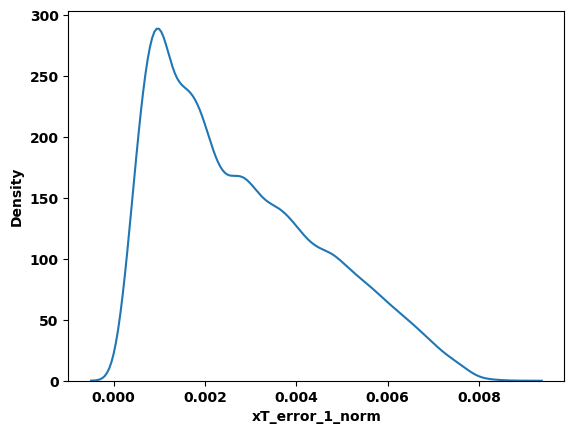

In [15]:
sns.kdeplot(data=df_errors, x='xT_error_1_norm')

<Axes: xlabel='xT_error_1_norm', ylabel='Density'>

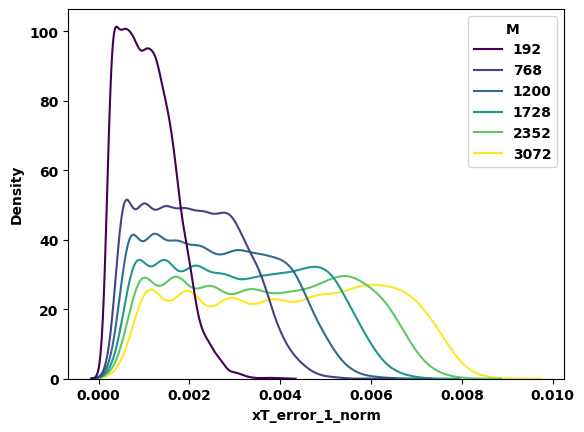

In [16]:
sns.kdeplot(data=df_errors, x='xT_error_1_norm', hue='M', palette='viridis')

<Axes: xlabel='xT_error_1_norm', ylabel='Density'>

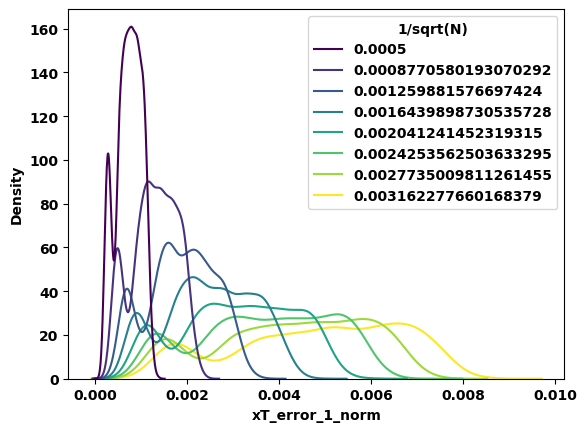

In [17]:
sns.kdeplot(data=df_errors, x='xT_error_1_norm', hue='1/sqrt(N)', palette='viridis')

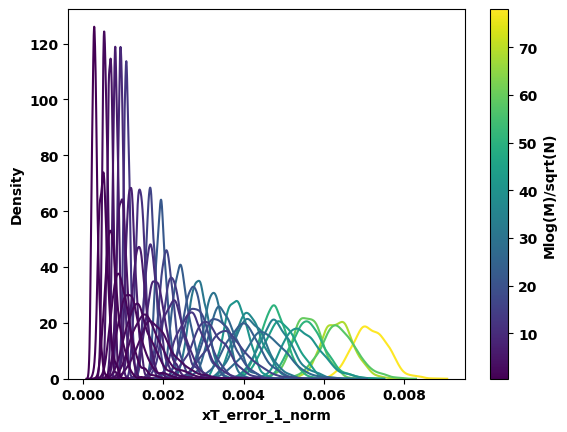

In [18]:
fig, ax = plt.subplots()
norm = plt.Normalize(df_errors['Mlog(M)/sqrt(N)'].min(), df_errors['Mlog(M)/sqrt(N)'].max())
sm = plt.cm.ScalarMappable(cmap='viridis', norm=norm)
sm.set_array([])

sns.kdeplot(
    data=df_errors, 
    x='xT_error_1_norm', 
    hue='Mlog(M)/sqrt(N)', 
    palette='viridis',
    hue_norm=norm,
    ax=ax
)

# Remove the legend
ax.get_legend().remove()

# Add a color bar
cbar = plt.colorbar(sm, ax=ax)
cbar.set_label('Mlog(M)/sqrt(N)')

plt.show()

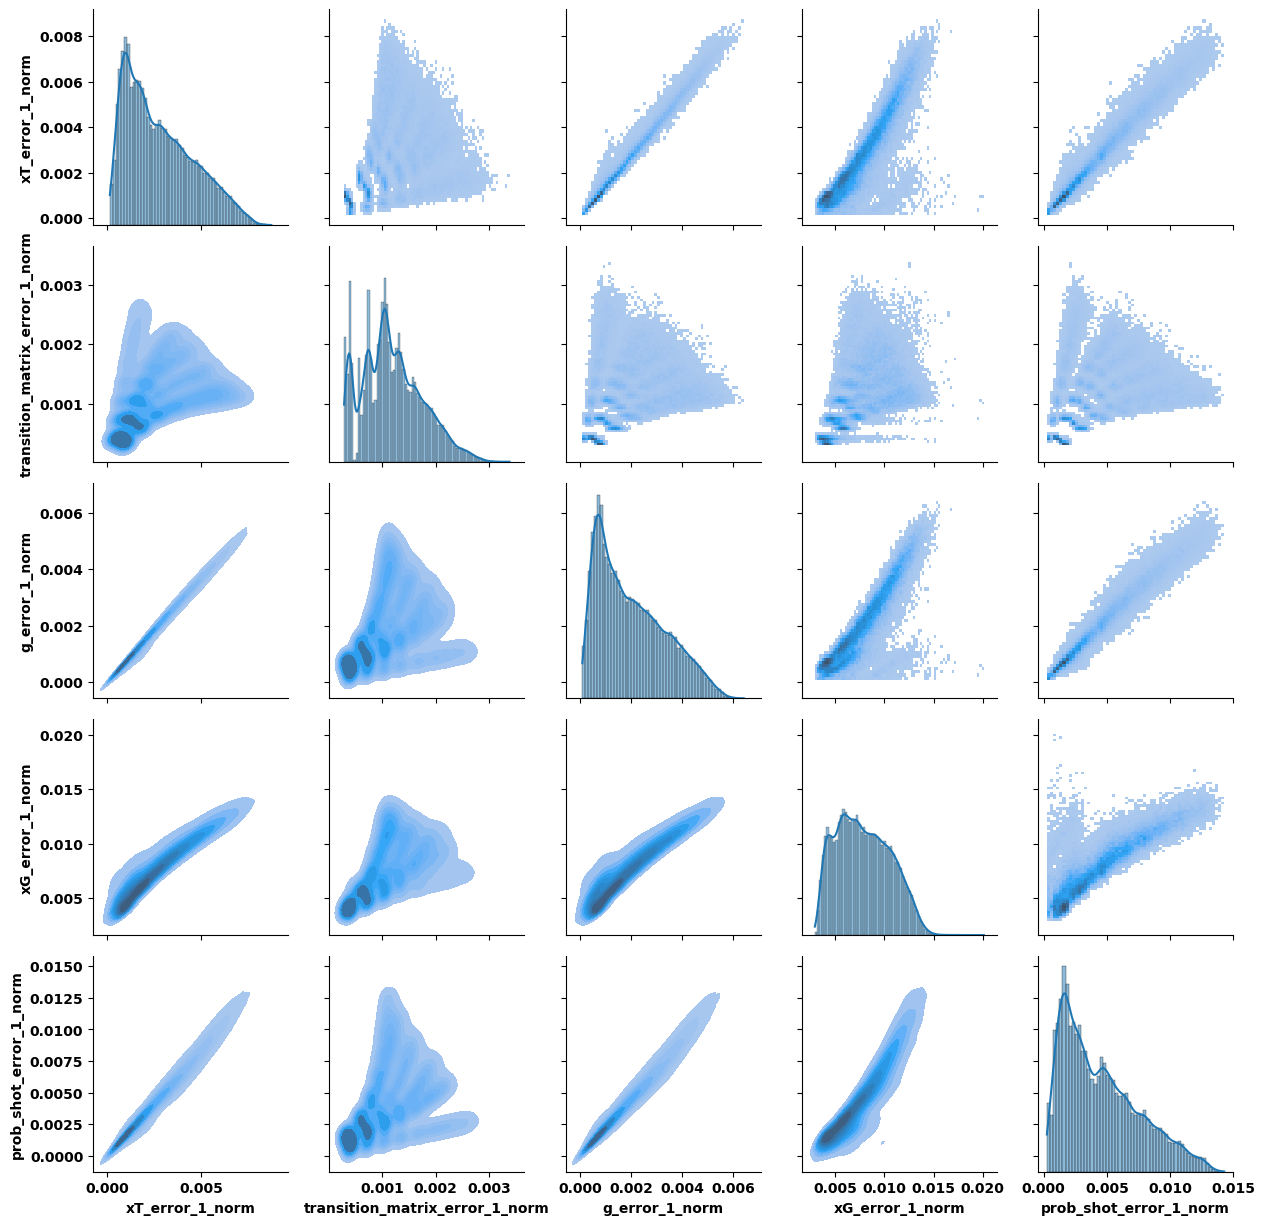

In [19]:
g = sns.PairGrid(df_errors[['xT_error_1_norm', 'transition_matrix_error_1_norm', 'g_error_1_norm', 'xG_error_1_norm', 'prob_shot_error_1_norm']])
g.map_upper(sns.histplot)
g.map_lower(sns.kdeplot, fill=True)
g.map_diag(sns.histplot, kde=True)